In [1]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA = df_DA.explode('job_skills')
df_DA_group = df_DA.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_Top_Pay = df_DA_group.sort_values('median',ascending = False).head(10)
df_DA_Skills = df_DA_group.sort_values('count',ascending = False).head(10).sort_values('median',ascending = False)

## Barplots

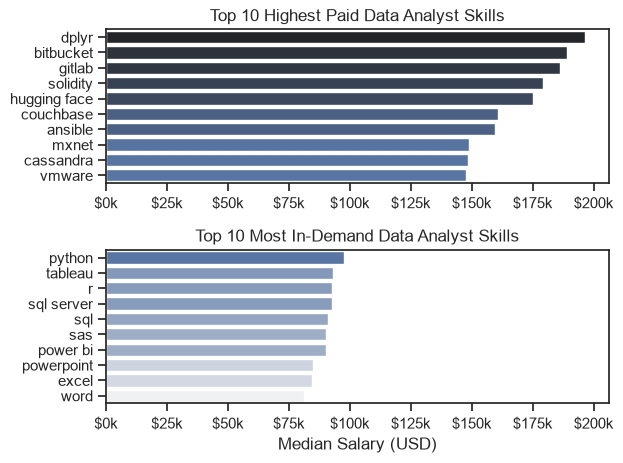

In [ ]:
import seaborn as sns


fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

#  Data Analyst Skills having Highest pay
# df_DA_Top_Pay[::-1].plot(kind ='barh', y = 'median', ax = ax[0], legend=False)
sns.barplot(data=df_DA_Top_Pay,x='median',y=df_DA_Top_Pay.index, hue='median', palette='dark:b_r', ax=ax[0])
ax[0].legend_.remove()
ax[0].set_title('Top 10 Highest Paid Data Analyst Skills')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
# ax[0].legend().set_visible(False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}k'))


# Most In-Demand Data Analyst Skills
# df_DA_Skills[::-1].plot(kind ='barh', y = 'median', ax = ax[1])
sns.barplot(data=df_DA_Skills,x='median',y=df_DA_Skills.index, hue='median', palette='light:b', ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Data Analyst Skills')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_ylabel('')
ax[1].legend().set_visible(False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}k'))
plt.tight_layout()

## Histograms

Text(0, 0.5, 'No of Jobs')

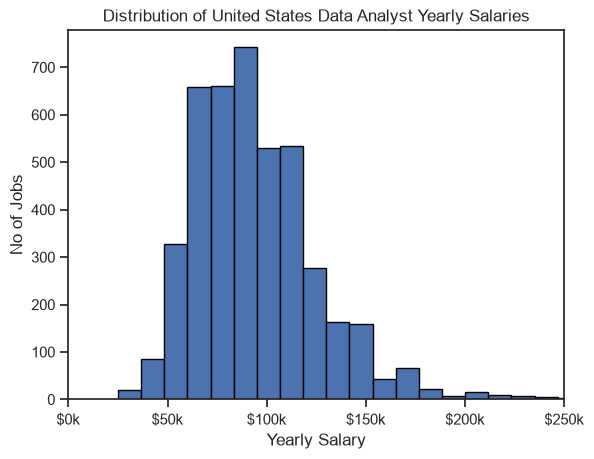

In [16]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States' )].copy()
df_DA['salary_year_avg'].plot(kind='hist', edgecolor = 'black', bins = 30)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}k'))
plt.xlim(0,250000)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('No of Jobs')

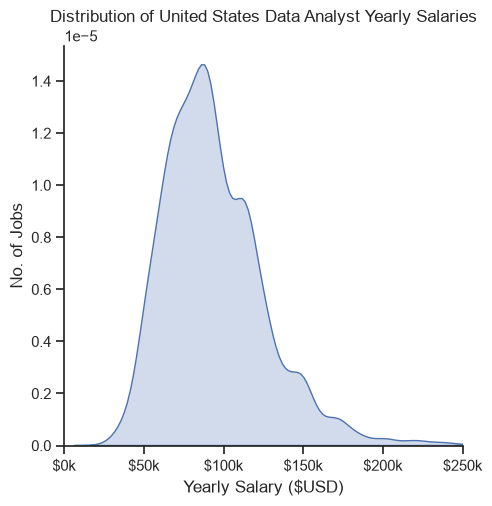

In [27]:

# df_DA['salary_year_avg'].plot(kind='hist', edgecolor = 'black', bins = 30)
sns.displot(data= df_DA['salary_year_avg'], kind='kde', fill = True)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}k'))
plt.xlim(0,250000)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('No. of Jobs')
plt.show()

## Boxplots

C:\Users\arjun\AppData\Local\Temp\ipykernel_7076\2168123306.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(box_list, tick_labels= job_list, vert=False)


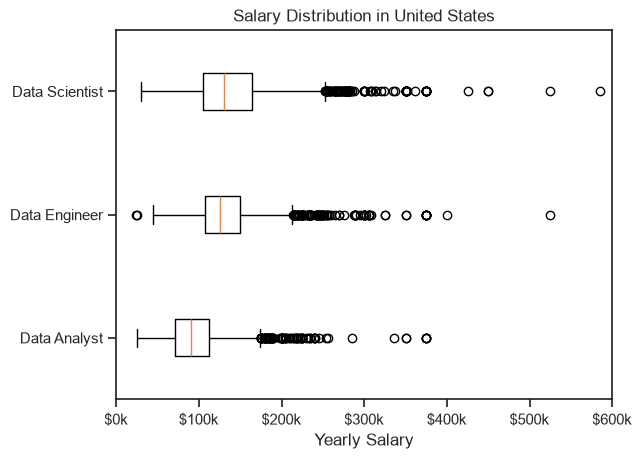

In [29]:
job_list = ['Data Analyst','Data Engineer','Data Scientist']

# Filter Jobs for job titles and country  
df_US = df[(df['job_title_short'].isin(job_list)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset ='salary_year_avg')

# listing series of job titles
box_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_list]


# ploting list of series
plt.boxplot(box_list, tick_labels= job_list, vert=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
plt.title('Salary Distribution in United States')
plt.xlim(0,600000)
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.show()

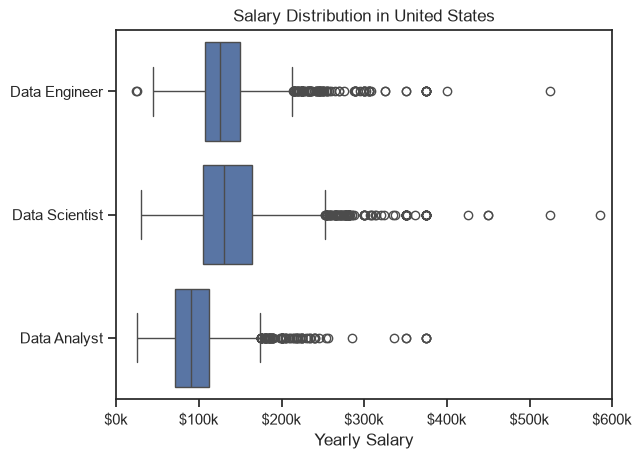

In [30]:
sns.boxplot(data=df_US, x='salary_year_avg', y = 'job_title_short')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
plt.title('Salary Distribution in United States')
plt.xlim(0,600000)
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.show()